# Next-Week Special Prediction — Model Comparison

In [1]:
from pathlib import Path
import os
import joblib
os.environ["LOKY_MAX_CPU_COUNT"] = "8"
os.environ.setdefault("MPLCONFIGDIR", "/tmp/discountmate-matplotlib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, precision_recall_curve,
    classification_report, ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier

DATA_FILE = Path("discount_price_final_dataset.csv")
if not DATA_FILE.exists():
    DATA_FILE = Path("ML/Price-Prediction/price_prediction_by_shivam/discount_price_final_dataset.csv")

data = pd.read_csv(DATA_FILE, parse_dates=["catalogue_start_date"])
data = data[data["classification_eligible"].eq(1)].copy()
print(f"Classification rows: {len(data):,}")
print(f"Next-week special rate: {data['target_is_special_next_week'].mean():.2%}")
data.head()

Classification rows: 44,640
Next-week special rate: 9.39%


,retailer,region,product_id,original_product_name,canonical_product_name,brand_key,pack_size,catalogue_start_date,week_index,catalogue_observed,...,weeks_since_last_special,week_of_year,month,quarter,season,target_week,target_is_special_next_week,target_discount_percent_next_week,classification_eligible,discount_regression_eligible
0,Coles,VIC METRO,P00000,Peters Drumstick 4 Pack-6 Pack 475mL-490mL,peters drumstick 4 pack 6 pack 475ml 490ml,peters,4 Pack; 6 Pack; 475mL; 490mL,2025-01-01,0,1,...,0.0,1,1,1,summer,2025-01-08,0.0,NaN,1,0
1,Coles,VIC METRO,P00000,Peters Drumstick 4 Pack-6 Pack 475mL-490mL,peters drumstick 4 pack 6 pack 475ml 490ml,peters,4 Pack; 6 Pack; 475mL; 490mL,2025-01-15,2,1,...,0.0,3,1,1,summer,2025-01-22,0.0,NaN,1,0
2,Coles,VIC METRO,P00000,Peters Drumstick 4 Pack-6 Pack 475mL-490mL,peters drumstick 4 pack 6 pack 475ml 490ml,peters,4 Pack; 6 Pack; 475mL; 490mL,2025-01-22,3,0,...,1.0,4,1,1,summer,2025-01-29,1.0,NaN,1,0
3,Coles,VIC METRO,P00000,Peters Drumstick 4 Pack-6 Pack 475mL-490mL,peters drumstick 4 pack 6 pack 475ml 490ml,peters,4 Pack; 6 Pack; 475mL; 490mL,2025-01-29,4,1,...,0.0,5,1,1,summer,2025-02-05,0.0,NaN,1,0
4,Coles,VIC METRO,P00000,Peters Drumstick 4 Pack-6 Pack 475mL-490mL,peters drumstick 4 pack 6 pack 475ml 490ml,peters,4 Pack; 6 Pack; 475mL; 490mL,2025-02-05,5,0,...,1.0,6,2,1,summer,2025-02-12,0.0,NaN,1,0


## Features and chronological split

In [2]:
features = [
    "catalogue_observed", "effective_price", "price_inferred", "price_trustworthy",
    "price_outlier", "is_special", "discount_percent", "history_count",
    "cold_start_product", "price_lag_1", "price_lag_2", "price_lag_4",
    "discount_lag_1", "avg_price_4w", "avg_price_8w",
    "special_frequency_4w", "special_frequency_8w", "weeks_since_last_special",
    "weeks_since_regular_price", "week_of_year", "month", "quarter",
    "season", "promo_type", "regular_price_source",
]

X = pd.get_dummies(
    data[features],
    columns=["season", "promo_type", "regular_price_source"],
    dummy_na=True,
    dtype=float,
)
y = data["target_is_special_next_week"].astype(int)

dates = sorted(data["catalogue_start_date"].unique())
validation_start = dates[-16]
test_start = dates[-8]

train_mask = data["catalogue_start_date"].lt(validation_start)
validation_mask = data["catalogue_start_date"].ge(validation_start) & data["catalogue_start_date"].lt(test_start)
test_mask = data["catalogue_start_date"].ge(test_start)

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_validation, y_validation = X.loc[validation_mask], y.loc[validation_mask]
X_test, y_test = X.loc[test_mask], y.loc[test_mask]

print(f"Train: {len(y_train):,} rows, ending before {pd.Timestamp(validation_start).date()}")
print(f"Validation: {len(y_validation):,} rows")
print(f"Test: {len(y_test):,} rows, starting {pd.Timestamp(test_start).date()}")


Train: 30,511 rows, ending before 2025-09-09
Validation: 7,435 rows
Test: 6,694 rows, starting 2025-11-05


## Train and compare models

In [3]:
positive_weight = (len(y_train) - y_train.sum()) / y_train.sum()

models = {
    "Logistic Regression": make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42),
    ),
    "Random Forest": make_pipeline(
        SimpleImputer(strategy="median"),
        RandomForestClassifier(
            n_estimators=200, max_depth=14, min_samples_leaf=2,
            class_weight="balanced_subsample", n_jobs=-1, random_state=42,
        ),
    ),
    "HistGradientBoosting": make_pipeline(
        SimpleImputer(strategy="median"),
        HistGradientBoostingClassifier(
            max_iter=200, learning_rate=0.07, max_leaf_nodes=31,
            class_weight="balanced", random_state=42,
        ),
    ),
    "XGBoost": make_pipeline(
        SimpleImputer(strategy="median"),
        XGBClassifier(
            n_estimators=250, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, scale_pos_weight=positive_weight,
            eval_metric="logloss", n_jobs=-1, random_state=42,
        ),
    ),
}

results = []
test_predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    validation_probability = model.predict_proba(X_validation)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_validation, validation_probability)
    validation_f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
    threshold = thresholds[np.argmax(validation_f1)]

    test_probability = model.predict_proba(X_test)[:, 1]
    prediction = (test_probability >= threshold).astype(int)
    test_predictions[name] = prediction

    results.append({
        "Model": name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, prediction),
        "Balanced Accuracy": balanced_accuracy_score(y_test, prediction),
        "Precision": precision_score(y_test, prediction, zero_division=0),
        "Recall": recall_score(y_test, prediction),
        "F1": f1_score(y_test, prediction),
        "ROC-AUC": roc_auc_score(y_test, test_probability),
        "PR-AUC": average_precision_score(y_test, test_probability),
    })

comparison = pd.DataFrame(results).sort_values(["PR-AUC", "F1"], ascending=False).reset_index(drop=True)
comparison.round(4)

,Model,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.6880,0.7702,0.6284,0.1853,0.4553,0.2634,0.6701,0.1853
1,XGBoost,0.6838,0.8370,0.5793,0.1983,0.2649,0.2268,0.6594,0.1816
2,HistGradientBoosting,0.7050,0.8327,0.5919,0.2055,0.2980,0.2432,0.6586,0.1796
3,Random Forest,0.4337,0.7788,0.5876,0.1640,0.3543,0.2242,0.6357,0.1645


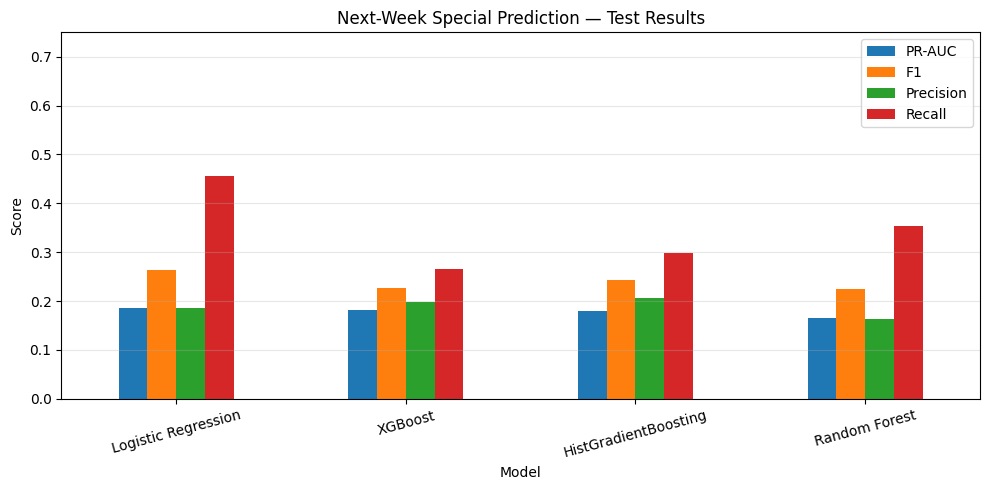

In [4]:
comparison.set_index("Model")[["PR-AUC", "F1", "Precision", "Recall"]].plot(
    kind="bar", figsize=(10, 5), ylim=(0, 0.75), rot=15
)
plt.title("Next-Week Special Prediction — Test Results")
plt.ylabel("Score")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Best model

Best model: Logistic Regression
PR-AUC: 0.185 (2.05x the 0.090 positive-rate baseline)
F1: 0.263 | Precision: 0.185 | Recall: 0.455
Validation-selected probability threshold: 0.688
PR-AUC is used to choose the best model because specials are uncommon and accuracy is dominated by non-special weeks.
The result should still be treated as a baseline: low precision shows that the available history does not yet identify promotions reliably.

Test classification report:
              precision    recall  f1-score   support

 Not special       0.94      0.80      0.86      6090
     Special       0.19      0.46      0.26       604

    accuracy                           0.77      6694
   macro avg       0.56      0.63      0.56      6694
weighted avg       0.87      0.77      0.81      6694



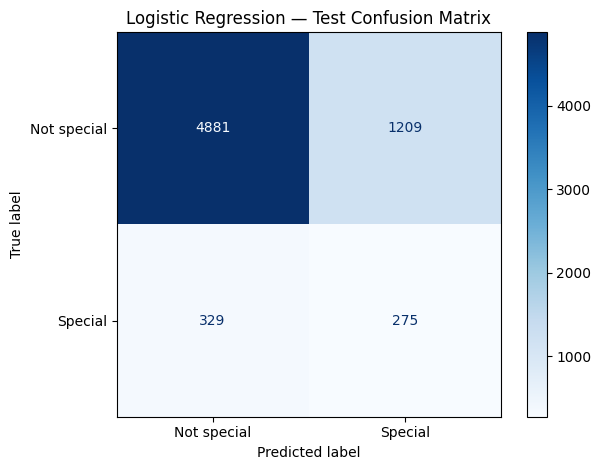

In [5]:
best = comparison.iloc[0]
best_name = best["Model"]
baseline = y_test.mean()
lift = best["PR-AUC"] / baseline

print(f"Best model: {best_name}")
print(f"PR-AUC: {best['PR-AUC']:.3f} ({lift:.2f}x the {baseline:.3f} positive-rate baseline)")
print(f"F1: {best['F1']:.3f} | Precision: {best['Precision']:.3f} | Recall: {best['Recall']:.3f}")
print(f"Validation-selected probability threshold: {best['Threshold']:.3f}")
print("PR-AUC is used to choose the best model because specials are uncommon and accuracy is dominated by non-special weeks.")
print("The result should still be treated as a baseline: low precision shows that the available history does not yet identify promotions reliably.")

print("\nTest classification report:")
print(classification_report(y_test, test_predictions[best_name], target_names=["Not special", "Special"], zero_division=0))

ConfusionMatrixDisplay.from_predictions(
    y_test, test_predictions[best_name], display_labels=["Not special", "Special"], cmap="Blues"
)
plt.title(f"{best_name} — Test Confusion Matrix")
plt.tight_layout()
plt.show()

## Train final model on all data

In [6]:
final_model = clone(models[best_name])

if best_name == "XGBoost":
    full_positive_weight = (len(y) - y.sum()) / y.sum()
    final_model.set_params(xgbclassifier__scale_pos_weight=full_positive_weight)

final_model.fit(X, y)
final_threshold = float(best["Threshold"])

model_bundle = {
    "model": final_model,
    "model_name": best_name,
    "threshold": final_threshold,
    "raw_features": features,
    "model_columns": X.columns.tolist(),
    "training_start": str(data["catalogue_start_date"].min().date()),
    "training_end": str(data["catalogue_start_date"].max().date()),
}

MODEL_FILE = DATA_FILE.parent / "discount_special_model.joblib"
joblib.dump(model_bundle, MODEL_FILE)

print(f"Final model: {best_name}")
print(f"Trained on all {len(y):,} eligible rows and {data['product_id'].nunique():,} products")
print(f"Date range: {data['catalogue_start_date'].min().date()} to {data['catalogue_start_date'].max().date()}")
print(f"Catalogue weeks: {data['catalogue_start_date'].nunique()}")
print(f"Saved: {MODEL_FILE.resolve()}")
print("The data covers one calendar year. Add catalogues from more years to learn true year-over-year changes.")

Final model: Logistic Regression
Trained on all 44,640 eligible rows and 6,696 products
Date range: 2025-01-01 to 2025-12-25
Catalogue weeks: 52
Saved: /Users/shivamsaini/Desktop/Deakin/SIT 782/DiscountMate_new/ML/Price-Prediction/price_prediction_by_shivam/discount_special_model.joblib
The data covers one calendar year. Add catalogues from more years to learn true year-over-year changes.
